# Building an ANN and a CNN with Keras — Handwritten Digit Recognition

This notebook is the hands-on follow-up to the "Neural Networks: From Perceptrons to CNNs" slides.
We're going to build TWO different networks, on the exact same data, so we can see how they compare:

- **Part 1 — an ANN** (Artificial Neural Network): plain `Dense` layers, exactly like Part 2 of the slides.
- **Part 2 — a CNN** (Convolutional Neural Network): `Conv2D` + `MaxPooling2D` layers, exactly like Part 4 of the slides.

**What we'll do, in order:**
1. Load a real dataset of handwritten digit images
2. Look at a few digits before doing anything to them
3. Prepare the images, and split into train/test sets
4. **Part 1:** Build, compile, train, and evaluate an ANN
5. **Part 2:** Build, compile, train, and evaluate a CNN on the SAME data
6. Compare the two, and look at real predictions from each

Run each cell top to bottom using **Shift + Enter**. Every line of code has a comment explaining exactly what it does —
you shouldn't need any extra explanation to follow along.

## Step 1 — Import the Tools We Need

In [1]:
# numpy helps us work with numbers and arrays
import numpy as np

# matplotlib is what we use to draw charts and pictures
import matplotlib.pyplot as plt

# load_digits gives us a real dataset of handwritten digit images, built into scikit-learn
from sklearn.datasets import load_digits

# train_test_split splits our data into a training set and a test set
from sklearn.model_selection import train_test_split

# tensorflow is the library that keras (the tool we'll build our networks with) lives inside
import tensorflow as tf

# keras is the friendly, high-level part of tensorflow used to build neural networks
from tensorflow import keras

# layers gives us the building blocks (Dense, Flatten, Conv2D, MaxPooling2D) we'll stack to build our networks
from tensorflow.keras import layers

# lock in the "randomness" so everyone gets the exact same results every time
np.random.seed(42)
tf.random.set_seed(42)

# a simple message to confirm everything loaded properly, and which tensorflow version we have
print("TensorFlow version:", tf.__version__)
print("Ready to go!")

TensorFlow version: 2.20.0
Ready to go!


## Step 2 — Load a Real Dataset of Handwritten Digits

We're using scikit-learn's built-in **digits dataset**: 1,797 real handwritten digit images (0-9),
scanned and scaled down to a small 8x8 pixel grid. It's a real, widely-used teaching dataset,
and it loads instantly with no downloading needed.

In [2]:
# load_digits() hands back the dataset already bundled with images and their correct labels
digits = load_digits()

# .images is the array of pictures: (number_of_images, height_in_pixels, width_in_pixels)
all_images = digits.images

# .target is the array of correct answers -- a digit from 0-9 for every image
all_labels = digits.target

# print the shape of the images: 1797 images, each 8 pixels tall and 8 pixels wide
print("Images shape:", all_images.shape)

# print one label so we can see what the "answer key" looks like
print("Example label:", all_labels[0])

Images shape: (1797, 8, 8)
Example label: 0


## Step 3 — Look at a Few Digits Before We Do Anything to Them

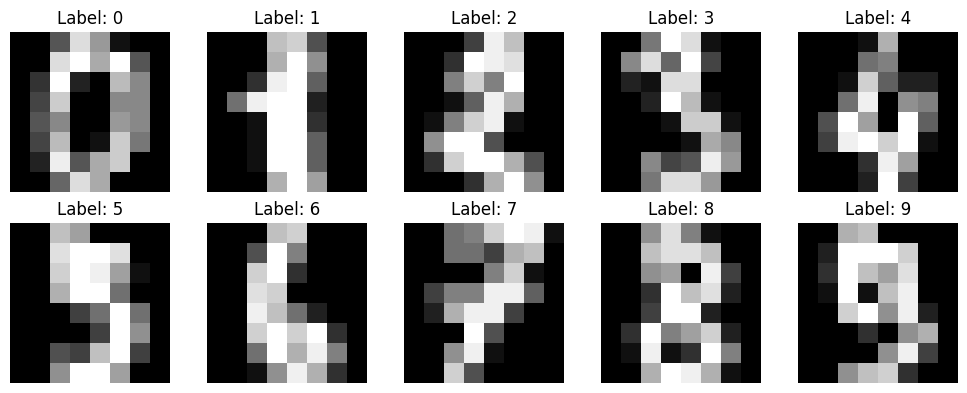

In [3]:
# make the picture a reasonable size
plt.figure(figsize=(10, 4))

# loop through the first 10 images in the dataset
for i in range(10):

    # create a small subplot: 2 rows, 5 columns, position i+1
    plt.subplot(2, 5, i + 1)

    # show the image itself, using a grayscale color map since these are grayscale digits
    plt.imshow(all_images[i], cmap="gray")

    # use the real label as the title, so we can check the image matches its answer
    plt.title(f"Label: {all_labels[i]}")

    # turn off the x/y axis ticks -- they're just pixel coordinates, not useful here
    plt.axis("off")

# add spacing so the subplots don't overlap each other
plt.tight_layout()

# actually display the picture
plt.show()

## Step 4 — Prepare the Images, and Split Into Train/Test Sets

Right now, each pixel is a brightness value from 0 (black) to 16 (white). Neural networks train much better
when numbers are small, so we'll scale every pixel down to a range of 0 to 1. This step is called **normalization**.
We'll also hold back a portion of the images as a test set, so we can honestly check performance on digits
neither network has ever seen. Both the ANN and the CNN will be trained and tested on this EXACT same split,
so any difference we see later is a fair comparison.

In [4]:
# divide every pixel value by 16.0 (the maximum brightness in this dataset) so all values end up between 0.0 and 1.0
scaled_images = all_images / 16.0

# split the data: 80% for training, 20% held back for testing
# stratify=all_labels keeps the mix of digits 0-9 balanced in both the train and test sets
train_images, test_images, train_labels, test_labels = train_test_split(
    scaled_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

# print how many images ended up in each set
print("Training images:", train_images.shape[0])
print("Test images:", test_images.shape[0])

Training images: 1437
Test images: 360


# Part 1 — Building an ANN

Remember from the slides: a **Perceptron** is a weighted sum + bias, passed through an **Activation Function**.
An ANN is just many perceptrons, arranged in layers. Here's what we're stacking:

- **Flatten** — turns each 8x8 image into a single flat list of 64 numbers (a network of Dense layers needs a flat input, not a grid)
- **Dense(64, ReLU)** — a hidden layer of 64 perceptrons, using ReLU (our default choice for hidden layers)
- **Dense(32, ReLU)** — a second hidden layer of 32 perceptrons, also ReLU
- **Dense(10, Softmax)** — the output layer: 10 perceptrons, one per digit (0-9), using Softmax so the outputs become 10 probabilities that sum to 1

## Step 5 — Build the ANN

In [5]:
# Sequential means the layers are stacked one after another, in a single straight line
ann_model = keras.Sequential([

    # tell the model the shape of a single input image: 8 pixels tall, 8 pixels wide
    keras.Input(shape=(8, 8)),

    # flatten each 8x8 image into one flat row of 8*8 = 64 numbers
    layers.Flatten(),

    # first hidden layer: 64 perceptrons, ReLU activation -- our standard choice for hidden layers
    layers.Dense(64, activation="relu"),

    # second hidden layer: 32 perceptrons, also ReLU
    layers.Dense(32, activation="relu"),

    # output layer: 10 perceptrons (one per digit), Softmax turns their scores into probabilities
    layers.Dense(10, activation="softmax"),
], name="ANN")

# summary() prints a table of every layer, its output shape, and how many weights it has to learn
ann_model.summary()

Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6 — Compile the ANN

This is where we tell Keras two things from Part 3 of the slides:

- **Loss function**: since this is a classification problem with more than 2 classes, we use `sparse_categorical_crossentropy` (a version of Cross-Entropy Loss that works directly with plain integer labels like `5`, instead of needing them one-hot encoded)
- **Optimizer**: `adam` — the algorithm that actually performs the "Update" step of backpropagation, deciding exactly how much to nudge each weight

In [6]:
ann_model.compile(
    # adam is a smart, widely-used optimizer -- it's the standard default choice for the update step
    optimizer="adam",

    # cross-entropy loss for classification -- "sparse" means our labels are plain integers (0-9), not one-hot vectors
    loss="sparse_categorical_crossentropy",

    # track accuracy (percent of images correctly classified) as we train, so it's easy to read
    metrics=["accuracy"],
)

# a simple message to confirm compiling finished
print("ANN compiled!")

ANN compiled!


## Step 7 — Train the ANN

This is the training loop from the slides, running for real: forward pass, compute loss, backward pass, update weights
-- repeated over and over, in small batches, for several epochs (full passes through the training data).

In [ ]:
# fit() runs the actual training loop, and returns a "history" of how loss/accuracy changed each epoch
ann_history = ann_model.fit(
    train_images,                  # the input images to learn from
    train_labels,                  # the correct answers (digit labels) for those images
    epochs=40,                     # how many full passes through the training data to make
    batch_size=16,                 # how many images to look at before each weight update
    validation_split=0.15,         # hold back 15% of the training data to check progress on unseen data each epoch
    verbose=0,                     # stay quiet here -- we'll plot the results instead of printing every epoch
)

# a simple message to confirm training finished
print("ANN training finished!")

## Step 8 — Plot the ANN's Loss and Accuracy Curves

In [ ]:
# make the picture wide enough for two charts side by side
plt.figure(figsize=(12, 4))

# ---- left chart: loss ----
plt.subplot(1, 2, 1)

# ann_history.history is a dictionary Keras filled in during training -- "loss" is the training loss per epoch
plt.plot(ann_history.history["loss"], label="Training Loss")

# "val_loss" is the loss on the held-back validation data per epoch
plt.plot(ann_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN — Loss Over Time")
plt.legend()

# ---- right chart: accuracy ----
plt.subplot(1, 2, 2)

# "accuracy" is the training accuracy per epoch
plt.plot(ann_history.history["accuracy"], label="Training Accuracy")

# "val_accuracy" is the accuracy on the held-back validation data per epoch
plt.plot(ann_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN — Accuracy Over Time")
plt.legend()

# add spacing so the two charts don't overlap
plt.tight_layout()

# actually display the picture
plt.show()

**Reading this chart:** loss should trend downward and accuracy should trend upward as training goes on. If the validation line starts getting worse while the training line keeps improving, that's a sign the network is starting to memorize the training data instead of learning general patterns -- a problem called *overfitting*.

## Step 9 — Evaluate the ANN on Data It Has Never Seen

In [ ]:
# evaluate() runs the network on the test set and returns the loss and accuracy on THAT data
ann_test_loss, ann_test_accuracy = ann_model.evaluate(test_images, test_labels, verbose=0)

# print both numbers, with accuracy shown as a percentage
print(f"ANN test loss: {ann_test_loss:.4f}")
print(f"ANN test accuracy: {ann_test_accuracy * 100:.2f}%")

# Part 2 — Building a CNN

Now let's build a second network for the SAME task, but this time using the CNN building blocks from Part 4 of the slides:
`Conv2D` layers to scan for visual patterns, and `MaxPooling2D` layers to shrink the data while keeping the strongest signal.

## Step 10 — Reshape the Images for the CNN

`Conv2D` layers expect input in the shape `(height, width, channels)` -- that last number is the color channel count
(1 for grayscale, 3 for RGB color). Our images are currently just `(height, width)`, so we need to add that channel dimension.
This is purely a reshaping step -- the actual pixel values don't change at all.

In [ ]:
# reshape adds a channel dimension of size 1 (grayscale) to the end of every image
# -1 tells numpy "keep this dimension (number of images) whatever it already is"
train_images_cnn = train_images.reshape(-1, 8, 8, 1)
test_images_cnn = test_images.reshape(-1, 8, 8, 1)

# print the new shape to confirm the extra dimension was added correctly
print("ANN-shaped training images:", train_images.shape)
print("CNN-shaped training images:", train_images_cnn.shape)

## Step 11 — Build the CNN

Here's what we're stacking, matching Part 4's architecture diagram exactly:

- **Conv2D(8 filters, 3x3, ReLU)** — 8 specialist filters, each scanning the image for one visual pattern
- **MaxPooling2D(2x2)** — shrinks the feature maps, keeping only the strongest signal from each 2x2 block
- **Conv2D(16 filters, 3x3, ReLU)** — a second round of filters, now looking at the already-simplified feature maps
- **MaxPooling2D(2x2)** — shrinks again
- **Flatten** — only NOW do we flatten, after the spatial scanning is done
- **Dense(32, ReLU)** — a familiar hidden layer, same as in the ANN
- **Dense(10, Softmax)** — the output layer, identical to the ANN's

In [ ]:
cnn_model = keras.Sequential([

    # tell the model the shape of a single input image: 8x8 pixels, 1 grayscale channel
    keras.Input(shape=(8, 8, 1)),

    # first convolutional layer: 8 filters, each a 3x3 sliding window, ReLU activation
    # padding="same" keeps the output the same width/height as the input (8x8 in, 8x8 out)
    layers.Conv2D(8, (3, 3), activation="relu", padding="same"),

    # shrink the 8x8 feature maps down to 4x4, keeping the strongest value from each 2x2 block
    layers.MaxPooling2D((2, 2)),

    # second convolutional layer: 16 filters this time, looking at the already-simplified 4x4 maps
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),

    # shrink again: 4x4 feature maps become 2x2
    layers.MaxPooling2D((2, 2)),

    # NOW flatten -- turn the final small 2x2x16 stack of feature maps into one flat list of numbers
    layers.Flatten(),

    # a familiar Dense hidden layer, exactly like the one in our ANN
    layers.Dense(32, activation="relu"),

    # output layer: 10 perceptrons (one per digit), Softmax turns their scores into probabilities
    layers.Dense(10, activation="softmax"),
], name="CNN")

# summary() prints a table of every layer, its output shape, and how many weights it has to learn
# compare this parameter count to the ANN's -- notice how filters being REUSED keeps this number small
cnn_model.summary()

## Step 12 — Compile the CNN

Exactly the same choices as the ANN: Cross-Entropy Loss (because this is still classification), and the Adam optimizer.
The only thing that changed is the ARCHITECTURE of the network above -- the training setup stays identical.

In [ ]:
cnn_model.compile(
    # adam is a smart, widely-used optimizer -- the same standard default choice as before
    optimizer="adam",

    # cross-entropy loss for classification -- same reasoning as the ANN
    loss="sparse_categorical_crossentropy",

    # track accuracy as we train, so it's easy to read
    metrics=["accuracy"],
)

# a simple message to confirm compiling finished
print("CNN compiled!")

## Step 13 — Train the CNN

Same training loop, same number of epochs, same batch size -- the only difference from the ANN is which model we're
calling `fit()` on, and that we're feeding it the CNN-shaped images (with the extra channel dimension) from Step 10.

In [ ]:
# fit() runs the training loop for the CNN, using the reshaped (8, 8, 1) images
cnn_history = cnn_model.fit(
    train_images_cnn,               # the CNN-shaped input images to learn from
    train_labels,                   # the correct answers (same labels as before)
    epochs=40,                      # same number of epochs as the ANN, for a fair comparison
    batch_size=16,                  # same batch size as the ANN
    validation_split=0.15,          # same validation split as the ANN
    verbose=0,                      # stay quiet here -- we'll plot the results instead
)

# a simple message to confirm training finished
print("CNN training finished!")

## Step 14 — Plot the CNN's Loss and Accuracy Curves

In [ ]:
# make the picture wide enough for two charts side by side
plt.figure(figsize=(12, 4))

# ---- left chart: loss ----
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["loss"], label="Training Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN — Loss Over Time")
plt.legend()

# ---- right chart: accuracy ----
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN — Accuracy Over Time")
plt.legend()

# add spacing so the two charts don't overlap
plt.tight_layout()

# actually display the picture
plt.show()

## Step 15 — Evaluate the CNN on Data It Has Never Seen

In [ ]:
# evaluate() runs the CNN on the same held-out test set the ANN used, so the comparison is fair
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_images_cnn, test_labels, verbose=0)

# print both numbers, with accuracy shown as a percentage
print(f"CNN test loss: {cnn_test_loss:.4f}")
print(f"CNN test accuracy: {cnn_test_accuracy * 100:.2f}%")

# Comparing the ANN and the CNN

Same digits, same train/test split, same number of epochs -- let's put both models side by side.

## Step 16 — Side-by-Side Comparison

In [ ]:
# count how many trainable weights each model has -- a measure of the model's size and complexity
ann_param_count = ann_model.count_params()
cnn_param_count = cnn_model.count_params()

# print a simple side-by-side comparison table using plain formatted text
print(f"{'Model':<8}{'Test Accuracy':>16}{'Parameters':>14}")
print(f"{'ANN':<8}{ann_test_accuracy * 100:>15.2f}%{ann_param_count:>14,}")
print(f"{'CNN':<8}{cnn_test_accuracy * 100:>15.2f}%{cnn_param_count:>14,}")

**A note on this comparison:** these images are tiny (8x8 pixels), so a plain ANN can already do quite well on them --
the gap between an ANN and a CNN grows much larger on bigger, more realistic photos, where spatial structure (edges, curves,
textures spread across many more pixels) matters a lot more. The building blocks you just used, though, are EXACTLY the
ones you'd reach for on a much larger image dataset -- only the size of the layers would change.

## Step 17 — Look at Real Predictions From Both Models

In [ ]:
# get the ANN's predicted digit for every test image (argmax picks the highest-probability class)
ann_predictions = np.argmax(ann_model.predict(test_images, verbose=0), axis=1)

# get the CNN's predicted digit for every test image
cnn_predictions = np.argmax(cnn_model.predict(test_images_cnn, verbose=0), axis=1)

# make the picture a reasonable size
plt.figure(figsize=(12, 5))

# look at the first 10 test images and both models' predictions
for i in range(10):

    # create a small subplot: 2 rows, 5 columns, position i+1
    plt.subplot(2, 5, i + 1)

    # show the test image itself
    plt.imshow(test_images[i], cmap="gray")

    # figure out if each model got this one right
    ann_correct = ann_predictions[i] == test_labels[i]
    cnn_correct = cnn_predictions[i] == test_labels[i]

    # green text if correct, red text if wrong, for each model separately
    ann_color = "green" if ann_correct else "red"
    cnn_color = "green" if cnn_correct else "red"

    # build a two-line title: ANN's guess and CNN's guess, plus the real answer
    plt.title(f"ANN: {ann_predictions[i]}  CNN: {cnn_predictions[i]}\nActual: {test_labels[i]}", fontsize=9)

    # turn off axis ticks
    plt.axis("off")

# add spacing so the subplots don't overlap
plt.tight_layout()

# actually display the picture
plt.show()

Let's specifically find a digit where the two models DISAGREED with each other -- these are the most interesting cases to look at.

In [ ]:
# np.where finds every index where the ANN and CNN predicted something different from each other
disagreement_indices = np.where(ann_predictions != cnn_predictions)[0]

# print how many test images the two models disagreed on
print(f"The ANN and CNN disagreed on {len(disagreement_indices)} out of {len(test_labels)} test images")

# only look closely at a disagreement if one actually happened
if len(disagreement_indices) > 0:

    # grab the first disagreement so we can look at it closely
    first_disagreement = disagreement_indices[0]

    # show that single image, larger, so it's easy to inspect
    plt.figure(figsize=(3, 3))
    plt.imshow(test_images[first_disagreement], cmap="gray")
    plt.title(
        f"ANN said: {ann_predictions[first_disagreement]}\n"
        f"CNN said: {cnn_predictions[first_disagreement]}\n"
        f"Actual: {test_labels[first_disagreement]}"
    )
    plt.axis("off")
    plt.show()
else:
    # rare, but worth telling the students if both models agreed on every single test image
    print("The ANN and CNN agreed on every single test image this run!")

## Recap

- We loaded ONE real dataset of 1,797 handwritten digit images and split it into training and test sets.
- **Part 1 (ANN):** `Flatten` → `Dense(64, ReLU)` → `Dense(32, ReLU)` → `Dense(10, Softmax)` -- the Perceptron and layer-stacking ideas from Parts 1-2 of the slides.
- **Part 2 (CNN):** `Conv2D(8)` → `MaxPool` → `Conv2D(16)` → `MaxPool` → `Flatten` → `Dense(32, ReLU)` → `Dense(10, Softmax)` -- the convolution and pooling ideas from Part 4.
- Both models were compiled with the same Cross-Entropy Loss and Adam optimizer, and trained with the exact same settings, so the comparison between them is fair.
- We compared test accuracy AND parameter count, and looked at real predictions from both models side by side, including a genuine disagreement between them.

That's the complete path from raw pixels to two different working neural networks -- and now you've seen, hands-on, exactly
why a CNN's extra structure exists: it's built specifically to take advantage of the spatial patterns that a plain ANN has to ignore.

In [ ]:
# Re‑build the ANN with tanh instead of relu
ann_tanh = keras.Sequential([
    keras.Input(shape=(8, 8)),
    layers.Flatten(),
    layers.Dense(64, activation="tanh"),
    layers.Dense(32, activation="tanh"),
    layers.Dense(10, activation="softmax")
])
ann_tanh.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_tanh = ann_tanh.fit(train_images, train_labels, epochs=40, batch_size=16, validation_split=0.15, verbose=0)
print("Tanh test accuracy:", ann_tanh.evaluate(test_images, test_labels, verbose=0)[1])

In [ ]:
from tensorflow.keras.layers import Dropout

ann_dropout = keras.Sequential([
    keras.Input(shape=(8, 8)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    Dropout(0.2),                 # drop 20% of connections randomly during training
    layers.Dense(32, activation="relu"),
    Dropout(0.2),
    layers.Dense(10, activation="softmax")
])
ann_dropout.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
ann_dropout.fit(train_images, train_labels, epochs=40, batch_size=16, validation_split=0.15, verbose=0)
print("Dropout test accuracy:", ann_dropout.evaluate(test_images, test_labels, verbose=0)[1])

In [ ]:
cnn_bigger = keras.Sequential([
    keras.Input(shape=(8, 8, 1)),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])
cnn_bigger.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn_bigger.fit(train_images_cnn, train_labels, epochs=40, batch_size=16, validation_split=0.15, verbose=0)
print("Bigger CNN test accuracy:", cnn_bigger.evaluate(test_images_cnn, test_labels, verbose=0)[1])

In [ ]:
ann_sgd = keras.Sequential([
    keras.Input(shape=(8, 8)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])
ann_sgd.compile(optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
ann_sgd.fit(train_images, train_labels, epochs=40, batch_size=16, validation_split=0.15, verbose=0)
print("SGD test accuracy:", ann_sgd.evaluate(test_images, test_labels, verbose=0)[1])

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Get predictions from the ANN
preds = np.argmax(ann_model.predict(test_images, verbose=0), axis=1)

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(test_labels, preds, cmap="Blues")
plt.title("ANN Confusion Matrix")
plt.show()

In [ ]:
import time

# ANN
start = time.time()
ann_model.fit(train_images, train_labels, epochs=40, batch_size=16, validation_split=0.15, verbose=0)
ann_time = time.time() - start

# CNN
start = time.time()
cnn_model.fit(train_images_cnn, train_labels, epochs=40, batch_size=16, validation_split=0.15, verbose=0)
cnn_time = time.time() - start

print(f"ANN training time: {ann_time:.2f} seconds")
print(f"CNN training time: {cnn_time:.2f} seconds")